In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/cifar100/meta
/kaggle/input/cifar100/file.txt
/kaggle/input/cifar100/test
/kaggle/input/cifar100/train


# <span style="color: purple;"> **Step 1** | **DETECT GPU** </span>
Recent versions of TensorFlow automatically detect if there is a GPU available for computation.

In [3]:
import tensorflow as tf

tf.config.list_physical_devices('GPU')


2026-03-06 20:36:26.270679: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772829386.292351     487 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772829386.298795     487 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772829386.315715     487 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772829386.315755     487 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772829386.315758     487 computation_placer.cc:177] computation placer alr

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

# <span style="color: purple;"> **Step 2** | **IMPORT NECCESSARY LIBRARIES** </span>

The project will rely on TensorFlow and Keras to handle the image data, craft the model, and optimize it for best performance:

In [4]:
import warnings
warnings.filterwarnings('ignore')

import cv2
import numpy as np
import urllib.request
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from keras.datasets import cifar10


from keras.models import Sequential
from keras.layers import Dense, Conv2D, MaxPooling2D
from keras.layers import Dropout, Flatten, BatchNormalization
from keras.regularizers import l2
from keras.optimizers import Adam
from keras.callbacks import ReduceLROnPlateau, EarlyStopping
from keras.models import load_model

In [ ]:
#/kaggle/input/cifar100

# <span style="color: purple;"> **Step 3** | **DATASET PREPARATION AND EXPLORATION** </span>

Image classification with computer vision. Specifically, we will try to classify articles of images from the CIFAR-100 dataset

Download the CIFAR-100 dataset from Keras library

In [5]:
image_shape = tf.keras.datasets.cifar100
(X_shape, y_shape), (X_test, y_test) = image_shape.load_data(label_mode='fine')

Split original training data to training and validation sets

In [6]:
X_shape,X_valid, y_shape, y_valid = train_test_split(X_shape, y_shape, test_size = 0.1, random_state = 0)

Printing out the dimensions of our training, validation, and test datasets

In [7]:
print('Train Images Shape:      ', X_shape.shape)
print('Train Labels Shape:      ', y_shape.shape)

print('\nValidation Images Shape: ', X_valid.shape)
print('Validation Labels Shape: ', y_valid.shape)

print('\nTest Images Shape:       ', X_test.shape)
print('Test Labels Shape:       ', y_test.shape)

Train Images Shape:       (45000, 32, 32, 3)
Train Labels Shape:       (45000, 1)

Validation Images Shape:  (5000, 32, 32, 3)
Validation Labels Shape:  (5000, 1)

Test Images Shape:        (10000, 32, 32, 3)
Test Labels Shape:        (10000, 1)


Take an overview of the CIFAR-100 dataset

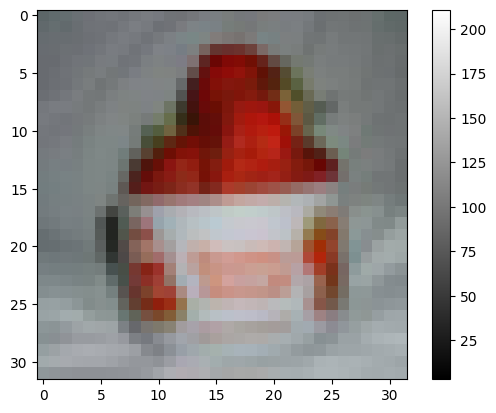

In [8]:
#Plot one of these images to see what it looks like
data_idx = 332

plt.figure()
plt.imshow(X_shape[data_idx], cmap='gray')
plt.colorbar()
plt.grid(False)
plt.show()

In [9]:
# Check label shape first
print(y_shape.shape)
print(y_shape[0])

(45000, 1)
[21]


100


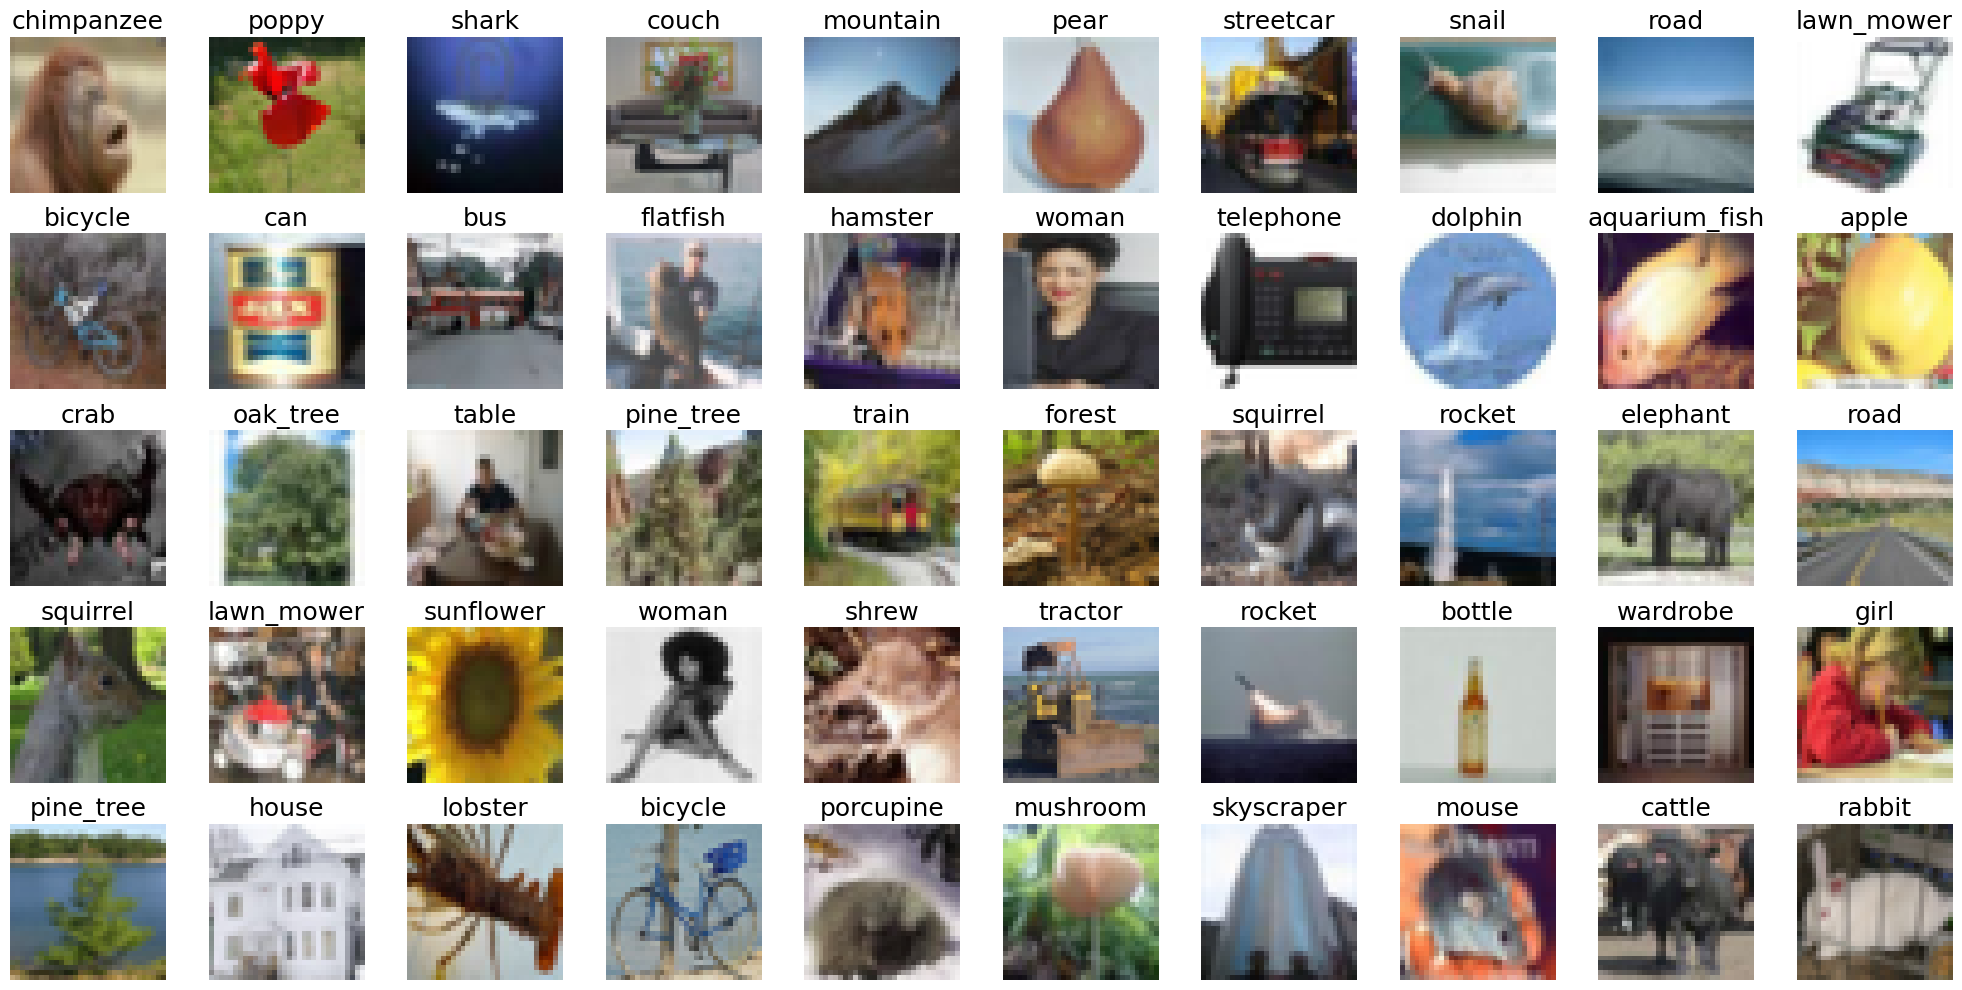

In [10]:
#CIFAR-10 classes
class_names = [
    'apple', 'aquarium_fish', 'baby', 'bear', 'beaver', 'bed', 'bee', 'beetle',
    'bicycle', 'bottle', 'bowl', 'boy', 'bridge', 'bus', 'butterfly', 'camel',
    'can', 'castle', 'caterpillar', 'cattle', 'chair', 'chimpanzee', 'clock',
    'cloud', 'cockroach', 'couch', 'crab', 'crocodile', 'cup', 'dinosaur',
    'dolphin', 'elephant', 'flatfish', 'forest', 'fox', 'girl', 'hamster',
    'house', 'kangaroo', 'keyboard', 'lamp', 'lawn_mower', 'leopard', 'lion',
    'lizard', 'lobster', 'man', 'maple_tree', 'motorcycle', 'mountain', 'mouse',
    'mushroom', 'oak_tree', 'orange', 'orchid', 'otter', 'palm_tree', 'pear',
    'pickup_truck', 'pine_tree', 'plain', 'plate', 'poppy', 'porcupine',
    'possum', 'rabbit', 'raccoon', 'ray', 'road', 'rocket', 'rose', 'sea',
    'seal', 'shark', 'shrew', 'skunk', 'skyscraper', 'snail', 'snake',
    'spider', 'squirrel', 'streetcar', 'sunflower', 'sweet_pepper', 'table',
    'tank', 'telephone', 'television', 'tiger', 'tractor', 'train', 'trout',
    'tulip', 'turtle', 'wardrobe', 'whale', 'willow_tree', 'wolf', 'woman', 'worm'
]
#Create a new figure
fig, axes = plt.subplots(5, 10, figsize=(20, 10))

#Loop over the first 50 images

for i, ax in enumerate(axes.flat):
    #Design subplot
    ax.imshow(X_shape[i])
    ax.set_title(class_names[y_shape[i][0]], fontsize=18)
    ax.axis('off')
    #Display images

#Print the class_names length
print(len(class_names))

#Display
plt.tight_layout()
plt.show()

# <span style="color: purple;">**Step 4 | DATA PREPROCESSING**</span>

In the Data Preprocessing phase, we undertake essential preparatory measures to ensure our dataset is aptly primed for the modeling process.

# <span style="color: magenta;">**Step 4.1</span> | <span style="color: violet;">NORMALISATION OF IMAGE DATA** </span>

Convert the pixel values data type to float32 type, and then normalizes them by subtracting the mean and dividing by the standard deviation of the training set, enhancing the model's training efficiency and effectiveness

In [11]:
# Convert pixel values data type to float32
X_shape = X_shape.astype('float32')
X_test  = X_test.astype('float32')
X_valid = X_valid.astype('float32')

# Calculate the mean and standard deviation of the training images
mean = np.mean(X_shape)
std  = np.std(X_shape)

# Normalize the data
# The tiny value 1e-7 is added to prevent division by zero
X_shape = (X_shape-mean)/(std+1e-7)
X_test  = (X_test-mean) /(std+1e-7)
X_valid = (X_valid-mean)/(std+1e-7)

# <span style="color: magenta;">**Step 4.3</span> | <span style="color: violet;">ONE-HOT ENCODING OF LABELS** </span>

Convert the class labels to one-hot vectors to transform the categorical labels into a format suitable for multi-class classification by neural networks

In [12]:
from keras.utils import to_categorical

y_shape = to_categorical(y_shape, 100)
y_valid = to_categorical(y_valid, 100)
y_test  = to_categorical(y_test, 100)

# <span style="color: purple;">**Step 5 | BUILDING A NEURON**</span>

Neurons are the fundamental building blocks to a neural network. Just like how human neurons send an electrical impulse under specific stimuli, artificial neural networks similarly result in a numerical output with a given numerical input.

# <span style="color: magenta;">**Step 5.1</span> | <span style="color: violet;">MATH** </span>

Neurons are often exposed to multivariate data. Build a neuron that takes each pixel value (which is between 0 and 255), and assign it a weight.

In [13]:
number_of_classes = 100

model_1 = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(32, 32, 3)),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Conv2D(128, (3,3), activation='relu'),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(number_of_classes, activation='softmax')
])

model_1.summary()

I0000 00:00:1772829459.255779     487 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        25,700 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 643,492 (2.45 MB)

 Trainable params: 643,492 (2.45 MB)

 Non-trainable params: 0 (0.00 B)

For each pixel, there should be a weight for each of our ten classes.

In [14]:
shape_height = 21
shape_width = 21

number_of_weights = shape_height * shape_width * number_of_classes
number_of_weights

44100

The weights make up 4,4100 parameters. Where do the other ten come from? It's each of the 10 neurons biases, the b in y = mx + b.

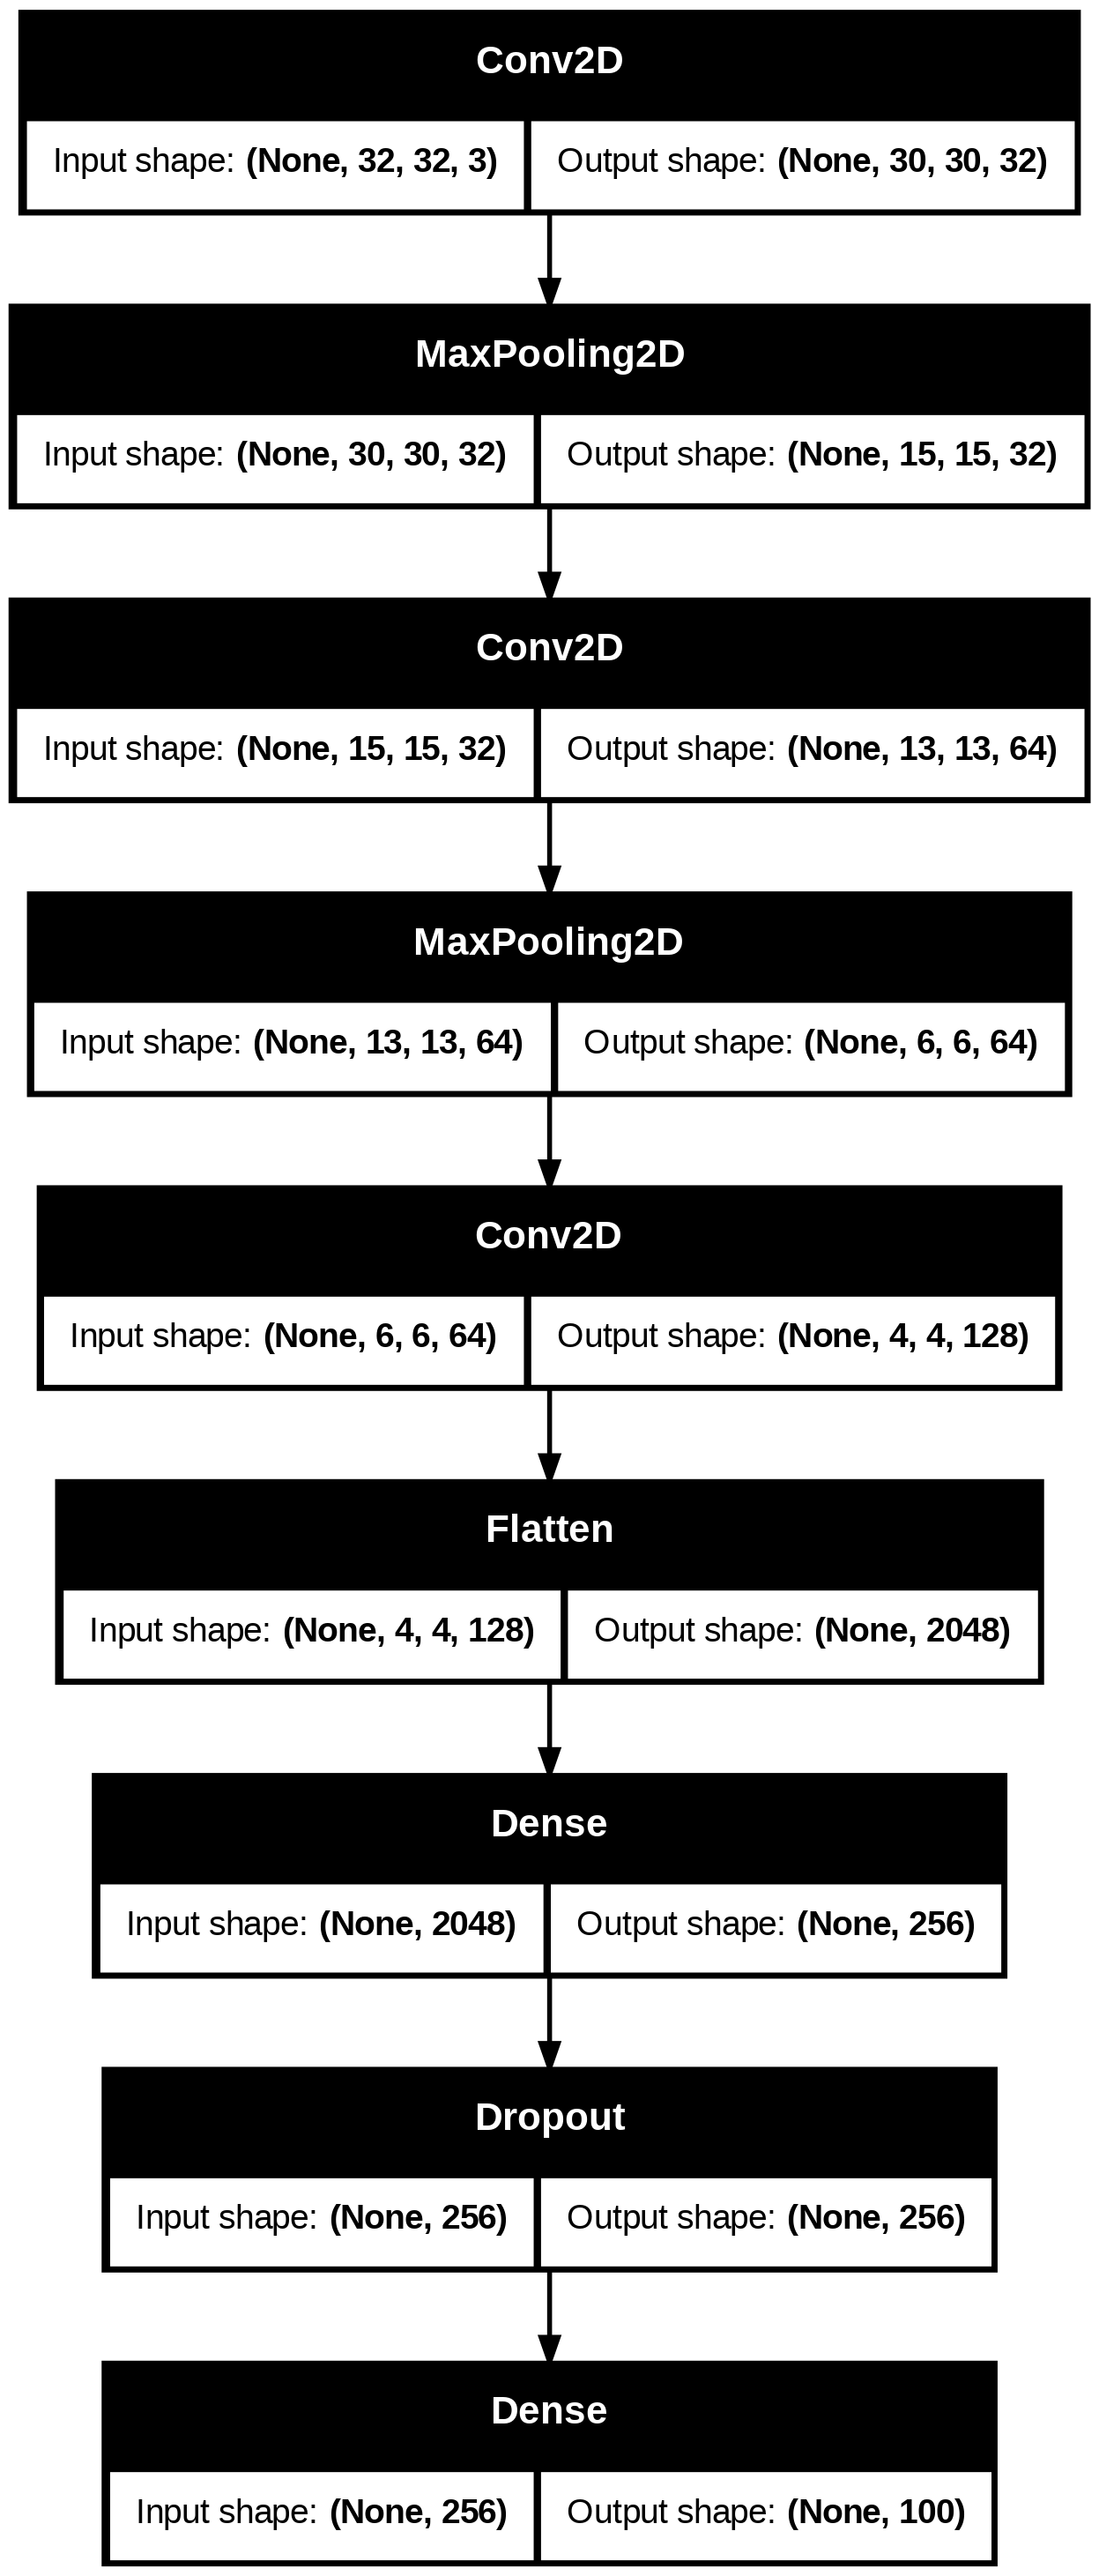

In [15]:
tf.keras.utils.plot_model(model_1, show_shapes=True)

# <span style="color: purple;">**Step 6 | DEFINE CNN MODEL ARCHITECTURE**</span>

Define is inspired from the VGG16 network. It contains multiple convolutional layers followed by max-pooling and dropout layers, and finally a fully connected layer for classification.

In [23]:
model_1 = Sequential()
weight_decay = 0.0001

# Add input shape to the FIRST layer
model_1.add(BatchNormalization(input_shape=(32, 32, 3)))
model_1.add(Conv2D(filters=32, kernel_size=(3,3), padding='same', activation='relu', kernel_regularizer=l2(weight_decay)))
model_1.add(BatchNormalization())

model_1.add(MaxPooling2D(pool_size=(2, 2)))
model_1.add(Dropout(rate=0.2))

model_1.add(Conv2D(filters=64, kernel_size=(3,3), padding='same', activation='relu', kernel_regularizer=l2(weight_decay)))   
model_1.add(BatchNormalization())

model_1.add(Conv2D(filters=64, kernel_size=(3,3), padding='same', activation='relu', kernel_regularizer=l2(weight_decay)))
model_1.add(BatchNormalization())

model_1.add(MaxPooling2D(pool_size=(2, 2)))
model_1.add(Dropout(rate=0.3))

model_1.add(Conv2D(filters=128, kernel_size=(3,3), padding='same', activation='relu', kernel_regularizer=l2(weight_decay))) 
model_1.add(BatchNormalization())

model_1.add(Conv2D(filters=128, kernel_size=(3,3), padding='same', activation='relu', kernel_regularizer=l2(weight_decay)))
model_1.add(BatchNormalization())

model_1.add(MaxPooling2D(pool_size=(2, 2)))
model_1.add(Dropout(rate=0.4))

model_1.add(Conv2D(filters=256, kernel_size=(3,3), padding='same', activation='relu', kernel_regularizer=l2(weight_decay))) 
model_1.add(BatchNormalization())

model_1.add(Conv2D(filters=256, kernel_size=(3,3), padding='same', activation='relu', kernel_regularizer=l2(weight_decay)))
model_1.add(BatchNormalization())

model_1.add(MaxPooling2D(pool_size=(2, 2)))
model_1.add(Dropout(rate=0.5))
model_1.add(Flatten())

model_1.add(Dense(100, activation='softmax'))



Display the detailed architecture of the model:

In [24]:
model_1.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ batch_normalization_16          │ (None, 32, 32, 3)      │            12 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_19          │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_20          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_21          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 4, 4, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_22          │ (None, 4, 4, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 4, 4, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_23          │ (None, 4, 4, 256)      │         1,024 │
│ (BatchNormalization)            │                        │             

 Total params: 1,269,232 (4.84 MB)

 Trainable params: 1,267,370 (4.83 MB)

 Non-trainable params: 1,862 (7.27 KB)

# <span style="color: purple;">**Step 7 | VISUALISE THE TRAINING DATA   AND                         VALIDATION  LOSS**</span>

In [25]:
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint

checkpoint = ModelCheckpoint(
    'model_checkpoint.keras',
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

data_generator = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
)

# Set the batch size for the training
batch_size = 64
# Set the maximum number of epochs for the training
epochs = 50
# Define the optimizer (Adam)
optimizer = Adam(learning_rate=0.0005)
# Compile the model
model_1.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

# Callbacks
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, min_lr=0.00001)
earlyStop = EarlyStopping(monitor='val_loss', patience=40, restore_best_weights=True, verbose=1)

# Fit the model
model_1.fit(data_generator.flow(X_shape, y_shape, batch_size=batch_size),
          epochs=epochs,
          validation_data=(X_valid, y_valid),
          callbacks=[reduce_lr, earlyStop], 
          verbose=2)

Epoch 1/300


I0000 00:00:1772830266.327061     552 service.cc:152] XLA service 0x7a6970001d80 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1772830266.327105     552 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1772830267.247112     552 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1772830274.237961     552 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


704/704 - 43s - 62ms/step - accuracy: 0.0683 - loss: 5.0464 - val_accuracy: 0.1408 - val_loss: 4.6375 - learning_rate: 5.0000e-04
Epoch 2/300
704/704 - 21s - 30ms/step - accuracy: 0.1364 - loss: 4.2239 - val_accuracy: 0.1534 - val_loss: 8.7544 - learning_rate: 5.0000e-04
Epoch 3/300
704/704 - 21s - 30ms/step - accuracy: 0.1805 - loss: 3.8391 - val_accuracy: 0.2266 - val_loss: 3.4501 - learning_rate: 5.0000e-04
Epoch 4/300
704/704 - 21s - 30ms/step - accuracy: 0.2185 - loss: 3.5792 - val_accuracy: 0.2584 - val_loss: 3.1723 - learning_rate: 5.0000e-04
Epoch 5/300


KeyboardInterrupt: 

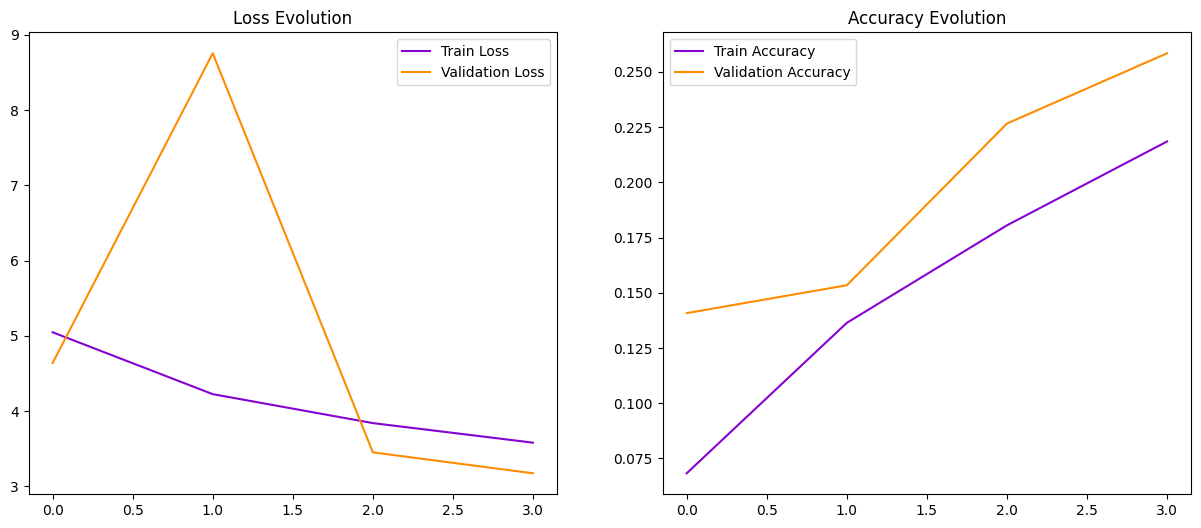

In [26]:
plt.figure(figsize=(15,6))

# Plotting the training and validation loss
plt.subplot(1, 2, 1)
plt.plot(model_1.history.history['loss'], label='Train Loss', color='#8502d1')
plt.plot(model_1.history.history['val_loss'], label='Validation Loss', color='darkorange')
plt.legend()
plt.title('Loss Evolution')

# Plotting the training and validation accuracy
plt.subplot(1, 2, 2)
plt.plot(model_1.history.history['accuracy'], label='Train Accuracy', color='#8502d1')
plt.plot(model_1.history.history['val_accuracy'], label='Validation Accuracy', color='darkorange')
plt.legend()
plt.title('Accuracy Evolution')

plt.show()

# <span style="color: purple;">**Step 8 | PREDICTION**</span>

The predict method to see the output of our model on a set of images, regardless of if they were in the original datasets or not.

In [27]:
#Evaluate the model on test data
test_loss, test_accuracy = model_1.evaluate(X_test, y_test, verbose=2)
print(f'Test Accuracy: {test_accuracy:.4f}')

313/313 - 2s - 7ms/step - accuracy: 0.2704 - loss: 3.7133
Test Accuracy: 0.2704


In [28]:
prediction = model_1.predict(X_test)
predicted_classes = np.argmax(prediction, axis=1)
true_classes = np.argmax(y_test, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.7375957..1.303461].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.7375957..1.303461].


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


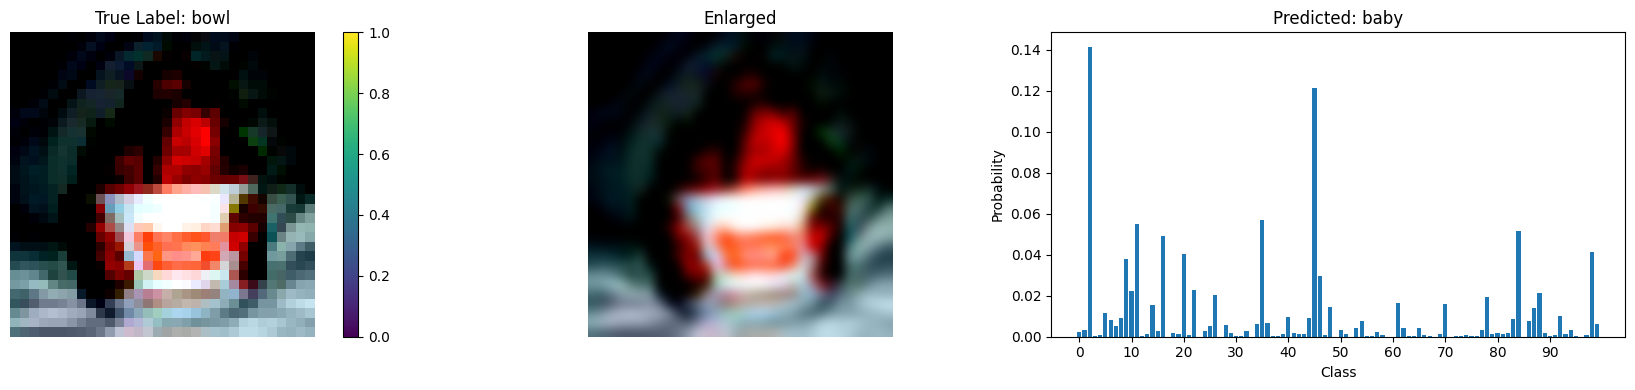

True label: bowl
Predicted: baby


In [40]:
data_idx = 332

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 4))

# Original image (small)
ax1.imshow(X_shape[data_idx])
ax1.set_title(f'True Label: {class_names[np.argmax(y_shape[data_idx])]}')
ax1.axis('off')

# Original image (enlarged/clear)
ax2.imshow(X_shape[data_idx], interpolation='bicubic')
ax2.set_title('Enlarged')
ax2.axis('off')

# Prediction bar chart
predictions = model_1.predict(X_shape[data_idx:data_idx+1]).flatten()
ax3.bar(range(number_of_classes), predictions)
ax3.set_xticks(range(0, number_of_classes, 10))
ax3.set_xlabel('Class')
ax3.set_ylabel('Probability')
predicted_class = np.argmax(predictions)
ax3.set_title(f'Predicted: {class_names[predicted_class]}')

plt.colorbar(ax1.images[0], ax=ax1)
plt.grid(False)
plt.tight_layout()
plt.show()

print("True label:", class_names[np.argmax(y_shape[data_idx])])
print("Predicted:", class_names[predicted_class])

The desired image:

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.7814571..1.8882796].


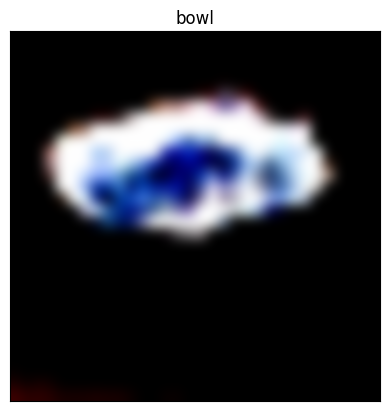

In [43]:
# Find a bowl image
bowl_idx = np.where(np.argmax(y_shape, axis=1) == class_names.index('bowl'))[0][0]

# Display the bowl image with bicubic interpolation for clarity
plt.imshow(X_shape[bowl_idx], interpolation='bicubic')
plt.xticks([])
plt.yticks([])
plt.grid(False)
plt.title('bowl')
plt.show()

In [48]:
model_1.save('cifar100_model.keras')

In [46]:
pip install kagglehub

Note: you may need to restart the kernel to use updated packages.


In [49]:
import kagglehub
import os

# Step 1 - Save the model first
model_1.save('cifar100_model.keras')

# Step 2 - Verify file exists
print(os.path.exists('cifar100_model.keras'))  # should print True

# Step 3 - Upload to Kaggle
MODEL_SLUG = 'cifar100-classification'
LOCAL_MODEL_DIR = '.'  # current directory where model is saved
VARIATION_SLUG = 'default'

kagglehub.model_upload(
    handle=f"cybertronic/{MODEL_SLUG}/keras/{VARIATION_SLUG}",
    local_model_dir=LOCAL_MODEL_DIR,
)

True
Uploading Model https://api.kaggle.com/models/cybertronic/cifar100-classification/keras/default ...
Model 'cifar100-classification' does not exist or access is forbidden for user 'cybertronic'. Creating or handling Model...
Model 'cifar100-classification' Created.
Starting upload for file ./model.png


Uploading: 100%|██████████| 150k/150k [00:02<00:00, 67.6kB/s]

Upload successful: ./model.png (147KB)
Starting upload for file ./cifar100_model.keras



Uploading: 100%|██████████| 15.3M/15.3M [00:04<00:00, 3.72MB/s]

Upload successful: ./cifar100_model.keras (15MB)
Starting upload for file ./.virtual_documents/__notebook_source__.ipynb



Uploading: 100%|██████████| 10.7k/10.7k [00:01<00:00, 6.42kB/s]

Upload successful: ./.virtual_documents/__notebook_source__.ipynb (10KB)


Your model instance has been created.
Files are being processed...
See at: https://api.kaggle.com/models/cybertronic/cifar100-classification/keras/default
